findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


Per‑epoch σ_TOA  = 0.70 µs
σ_white after 8 weekly scans   = 0.25 µs
σ_white after 1 yr (weekly)    = 0.10 µs
Red‑noise σ after 1 yr         = 0.00 µs
σ_dotnu after 5 yr             = 7.26e-23 s^-2


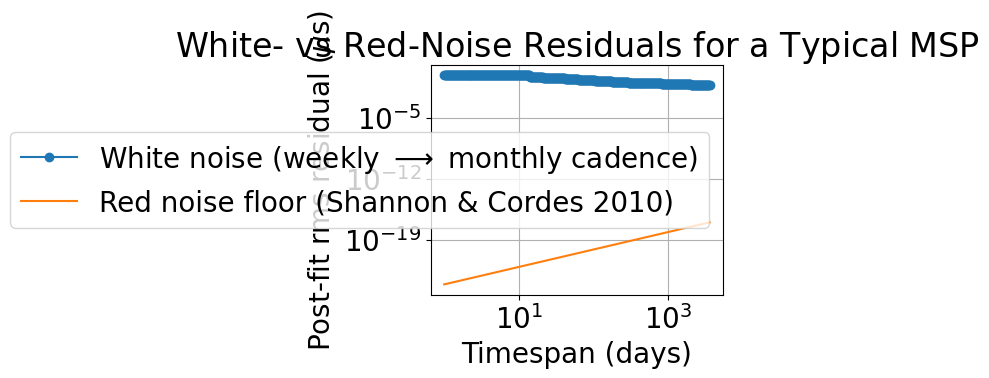

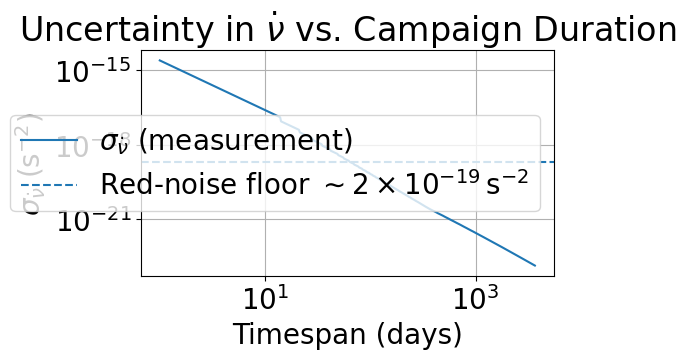

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


rcParams['font.family']      = 'serif'
rcParams['font.serif']       = ['EB Garamond']
rcParams['font.size']        = 20
rcParams['axes.unicode_minus'] = True
rcParams['axes.formatter.use_mathtext'] = False
rcParams['text.usetex'] = False

# -----------------------------
# 1. Define canonical MSP + telescope parameters
# -----------------------------
SEFD = 6.0          # Jy
B = 6.0e9           # Hz (6 GHz processed bandwidth)
T_int = 30 * 60     # 30 min in seconds
W_eff = 50e-6       # effective pulse width (s)
P_spin = 5e-3       # spin period (s)
nu_spin = 1 / P_spin
dot_nu = -1e-15     # s^-2  (absolute later)

# 2. Per–epoch template‑fitting error  (radiometer + jitter)
# Radiometer error (Downs & Reichley 1983 form, with S/N folded in):
sigma_SNR = 0.7e-6      # s, from analytic estimate in text (~0.7 µs)
# Jitter following Cordes & Shannon 2010
N_pulses = T_int / P_spin
N6 = N_pulses / 1e6
sigma_jitter = 0.28e-6 * (W_eff / 1e-3) * N6**-0.5  # W expressed in ms
sigma_TOA = np.sqrt(sigma_SNR**2 + sigma_jitter**2)  # total per epoch

# 3. Build time grid (1 day → 10 years)
t_days = np.logspace(0, np.log10(3650), 400)    # days
t_seconds = t_days * 86400
t_years = t_days / 365.25

# 4. Weekly cadence first year, then 15 epochs/yr thereafter
def N_epochs(t_day):
    if t_day <= 365.25:
        return max(1, np.floor(t_day / 7))
    else:
        # first year weekly + subsequent years at 15/yr
        return np.floor(365.25 / 7) + np.floor((t_day - 365.25) * 15 / 365.25)

N = np.array([N_epochs(td) for td in t_days])
sigma_white = sigma_TOA / np.sqrt(N)

# 5. Red‑noise floor using Shannon & Cordes (2010) scaling
C2 = np.exp(1.6)
alpha, beta, gamma = -1.4, 1.1, 2.0
sigma_red = C2 * (nu_spin)**alpha * abs(dot_nu)**beta * (t_years**gamma) * 1e-6  # convert µs→s

# 6. Uncertainty on dot_nu (Cramér‑Rao)
sigma_dotnu = np.sqrt(720 / N) * sigma_TOA / (t_seconds**2)

# -----------------------------
# 7. Diagnostic prints
# -----------------------------
print(f"Per‑epoch σ_TOA  = {sigma_TOA*1e6:.2f} µs")
print(f"σ_white after 8 weekly scans   = {sigma_TOA/np.sqrt(8)*1e6:.2f} µs")
print(f"σ_white after 1 yr (weekly)    = {sigma_TOA/np.sqrt(52)*1e6:.2f} µs")

idx_1yr = np.argmin(np.abs(t_days-365.25))
print(f"Red‑noise σ after 1 yr         = {sigma_red[idx_1yr]*1e6:.2f} µs")
print(f"σ_dotnu after 5 yr             = {sigma_dotnu[np.argmin(np.abs(t_days-5*365.25))]:.2e} s^-2")

# -----------------------------
# 8. Plot residual RMS (white vs red)
# -----------------------------
plt.figure(figsize=(6,4))
plt.loglog(t_days, sigma_white*1e6, marker='o', label="White noise (weekly $\longrightarrow$ monthly cadence)")
plt.loglog(t_days, sigma_red*1e6, label="Red noise floor (Shannon & Cordes 2010)")
plt.xlabel("Timespan (days)")
plt.ylabel("Post$‑$fit rms residual ($\mu$s)")
plt.title("White$‑$ vs Red$‑$Noise Residuals for a Typical MSP")
plt.legend()
plt.grid(True, which='major', axis='both')
plt.tight_layout()
plt.show()

# -----------------------------
# 9. Plot σ_dotnu vs time
# -----------------------------
plt.figure(figsize=(6,4))
plt.loglog(t_days, sigma_dotnu, label=r"$\sigma_{\dot\nu}$ (measurement)")
plt.axhline(2e-19, linestyle="--", label=r"Red$‑$noise floor $\sim2\times10^{-19}\,\mathrm{s^{-2}}$")
plt.xlabel("Timespan (days)")
plt.ylabel(r"$\sigma_{\dot\nu}$ (s$^{-2}$)")
plt.title("Uncertainty in $\dot\\nu$ vs. Campaign Duration")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


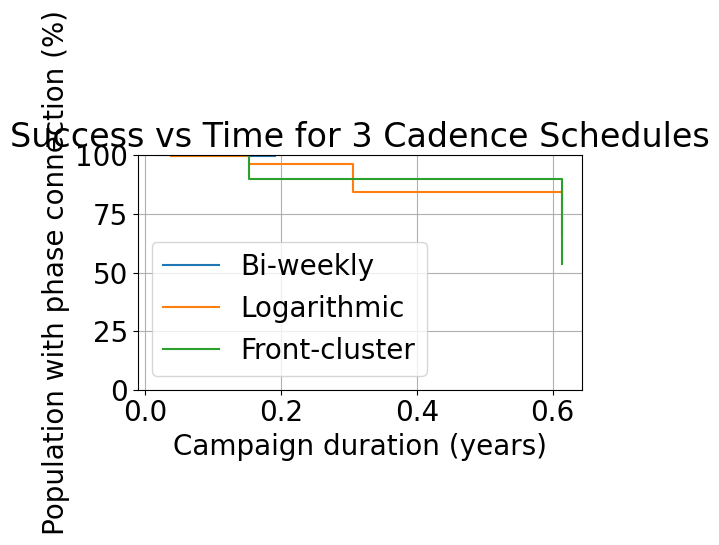

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

# ---------------------
# MSP population as before
# ---------------------
N_PSR = 5000
rng = np.random.default_rng(42)
P_ms  = 10**rng.normal(np.log10(3), 0.25, N_PSR)
P_sec = P_ms * 1e-3
log10_dotP = rng.uniform(-21, -18, N_PSR)
dotP  = 10**log10_dotP
dot_nu = -dotP / P_sec**2
sigma_TOA = 10**rng.normal(np.log10(0.7e-6), 0.25, N_PSR)

# ---------------------
# Schedules (weeks)
# ---------------------
scheds = {
    "Bi‑weekly":       [0, 2, 4, 6, 8, 10],          # weeks
    "Logarithmic":     [0, 2, 4, 8, 16, 32],
    "Front‑cluster":   [0, 1, 2, 8, 32]              # 1 discovery + 4 follow‑up (user list)
}
# Assume weeks→days
wk2day = 7

def rotation_safe(gap_days):
    gap_sec = gap_days * 86400
    return 0.5 * np.abs(dot_nu) * gap_sec**2 < 0.5

def frac_success(schedule_weeks):
    # cumulative success after each epoch
    successes = []
    times = []
    used_weeks = []
    for wk in schedule_weeks[1:]:   # skip discovery epoch at 0 for counting
        used_weeks.append(wk)
        timespan_days = (wk) * wk2day
        gaps = np.diff([0]+used_weeks)  # weeks
        max_gap_days = max(gaps)*wk2day
        safe_rot = rotation_safe(max_gap_days)
        N_epochs = len(used_weeks)+1  # include discovery
        sigma_white = sigma_TOA / np.sqrt(N_epochs)
        T_sec = timespan_days * 86400
        sig_nu = np.sqrt(12)*sigma_white /(P_sec*T_sec)
        good_nu = (sig_nu*P_sec) < 1e-7
        good = safe_rot & good_nu
        successes.append(good.mean()*100)
        times.append(timespan_days/365.25)  # yrs
    return times, successes

results = {}
for name, sc in scheds.items():
    t, f = frac_success(sc)
    results[name] = (t, f)

# ---------------------
# Plot cumulative success fraction
# ---------------------
plt.figure(figsize=(6,4))
for name, (t,f) in results.items():
    plt.step(t, f, where='post', label=name)
plt.xlabel("Campaign duration (years)")
plt.ylabel("Population with phase connection (%)")
plt.title("Success vs Time for 3 Cadence Schedules")
plt.ylim(0, 100)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


Phase‑connected success fraction after 1‑yr gap:
  3 EP [0,1,2] : 11.40400 %
  4 EP [0,1,25,50] : 0.55000 %
  5 EP [0,1,25,30,50] : 0.60000 %
  5 EP [0,1,2,3,50] : 0.07200 %


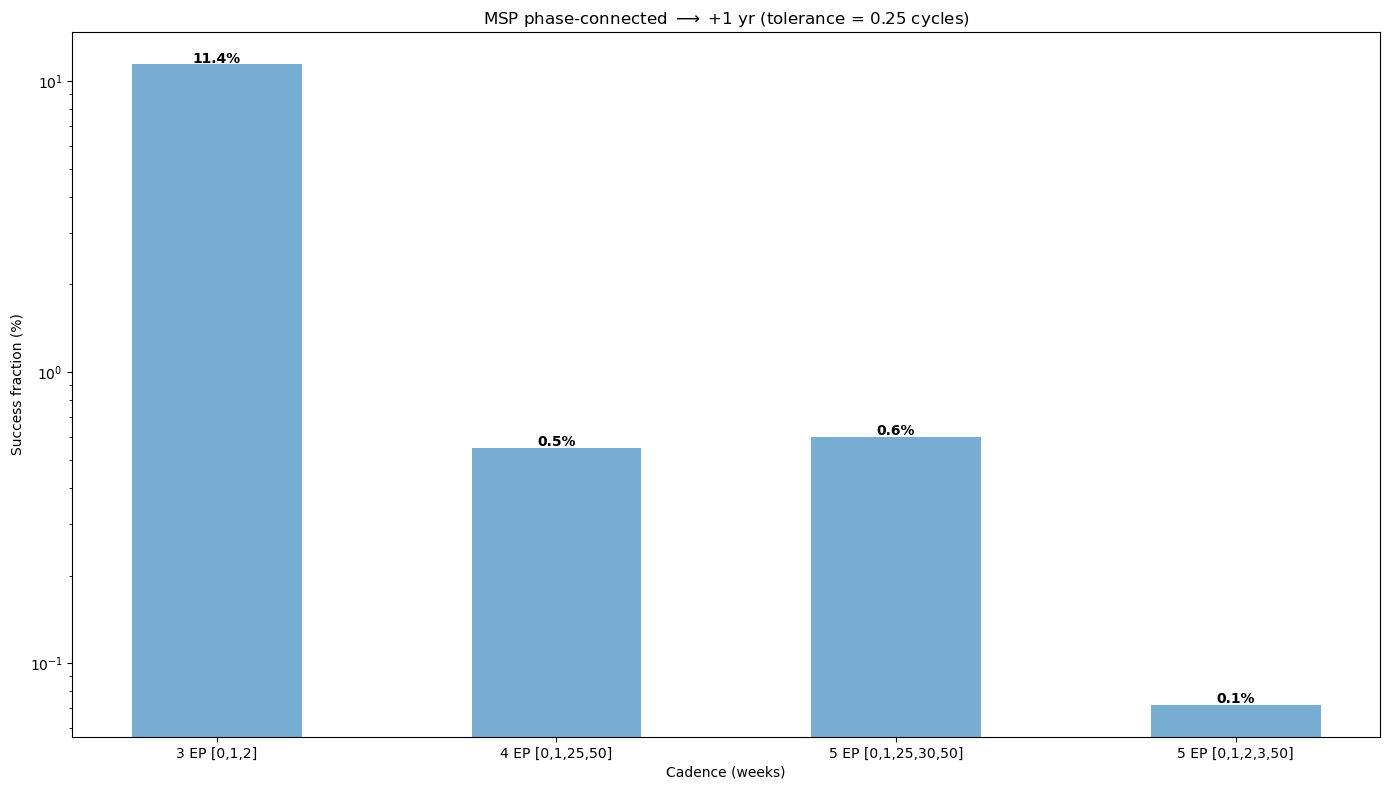

In [1]:
#!/usr/bin/env python3
"""
Simulate the fraction of MSPs that remain phase‑connected after a 1‑year gap
for different observing cadence schedules.

Author: Jakob + ChatGPT
Date  : 2025‑06‑03
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Generate an MSP population
# -------------------------------------------------
N_PSR = 50000
rng = np.random.default_rng(42)

# Spin period (ms) – log‑normal around 3 ms
P_ms = 10 ** rng.normal(np.log10(3.0), 0.25, N_PSR)
P_sec = P_ms * 1e-3

# Period derivative – uniform in log space
log10_dotP = rng.uniform(-21, -18, N_PSR)
dotP = 10 ** log10_dotP
dot_nu = -dotP / P_sec**2  # ν̇ = −Ṗ / P²

# Baseline white‑noise TOA uncertainty for a 30‑min dwell (seconds)
sigma_toa_base = 10 ** rng.normal(np.log10(0.7e-6), 0.25, N_PSR)

# Red‑noise amplitude (seconds at 1 yr) – 1–5 µs
A_red = rng.uniform(1, 5, N_PSR) * 1e-6

# DM‑noise amplitude (seconds at 1 yr) – 0.2–1 µs
A_dm = rng.uniform(0.2, 1.0, N_PSR) * 1e-6

# Scintillation S/N factor – log‑normal, σ=0.3 dex
scint_factor = 10 ** rng.normal(0, 0.3, N_PSR)

# -------------------------------------------------
# 2. Helper: robust fraction for a cadence schedule
# -------------------------------------------------
WK2SEC = 7 * 86400
FUTURE_GAP_YEARS = 1
FUTURE_GAP_SEC = FUTURE_GAP_YEARS * 365.25 * 86400

def robust_fraction_full(weeks, thresh=0.05, total_minutes=120):
    """
    Return the % of MSPs that will keep phase coherence over a 1‑year gap
    after observations at the specified 'weeks' epochs.

    Parameters
    ----------
    weeks : list-like
        Epoch timings (weeks since discovery).
    thresh : float
        Allowed 1‑σ phase uncertainty at the future gap (cycles).
    total_minutes : float
        Total telescope time available across all visits (minutes).
    """
    N_visits = len(weeks)
    tint_min = 30 #total_minutes / N_visits            # minutes per visit
    # White‑noise TOA uncertainty scales ∝ 1/√t_int
    sigma_toa = sigma_toa_base * np.sqrt(30.0 / tint_min) * scint_factor

    # Design matrix for ν and ν̇ fits
    t_sec = np.asarray(weeks) * WK2SEC
    t_rel = t_sec - t_sec[0]
    X = np.vstack((np.ones_like(t_rel),              # phase offset
                   t_rel,                            # ν term
                   0.5 * t_rel**2)).T                # ν̇ term
    XtX_inv = np.linalg.inv(X.T @ X)

    var_nu    = XtX_inv[1, 1] * sigma_toa**2
    var_nudot = XtX_inv[2, 2] * sigma_toa**2
    cov       = XtX_inv[1, 2] * sigma_toa**2

    dt = FUTURE_GAP_SEC
    # Prediction error on phase (cycles) propagated to the future gap
    rad = dt**2 * var_nu + 0.25 * dt**4 * var_nudot + 2.0 * dt**3 * cov
    det = np.sqrt(np.maximum(rad, 0.0)) / P_sec

    # Incremental red & DM noise accumulated over the next year
    T_obs_yr = weeks[-1] / 52.0
    incr_red = A_red * ((T_obs_yr + 1.0) ** 2 - T_obs_yr ** 2) / P_sec
    incr_dm  = A_dm  * ((T_obs_yr + 1.0) ** (5/3) - T_obs_yr ** (5/3)) / P_sec

    sigma_phase = np.sqrt(det**2 + incr_red**2 + incr_dm**2)

    # Largest internal gap → risk of cycle‑slip during the campaign
    gap_sec = np.max(np.diff(t_sec))
    drift_cycles = 0.5 * np.abs(dot_nu) * gap_sec**2 / P_sec

    ok = (sigma_phase < thresh) & (drift_cycles < thresh)
    return ok.mean() * 100.0

# -------------------------------------------------
# 3. Evaluate example cadence schedules
# -------------------------------------------------
schedules = {
    "3 EP [0,1,2]":  [0,1,2],
    "4 EP [0,1,25,50]":  [0,1,25,50],
    "5 EP [0,1,25,30,50]":  [0,1,25,30,50],
    "5 EP [0,1,2,3,50]": [0,1,2,3,50],
}

results = {name: robust_fraction_full(weeks,
                                      thresh=0.25,
                                      total_minutes=120)  # 4 × 30 min
           for name, weeks in schedules.items()}

# -------------------------------------------------
# 4. Present results
# -------------------------------------------------
print("Phase‑connected success fraction after 1‑yr gap:")
for name, frac in results.items():
    print(f"  {name:6s} : {frac:5.5f} %")

# Optional quick‑look bar plot
plt.figure(figsize=(14, 8))
percentages = [f"{v:.1f}%" for v in results.values()]
graph = plt.bar(results.keys(), results.values(), alpha=0.6, width=0.5)
i = 0
for p in graph:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    plt.text(x+width/2,
             y+height*1.01,
             str(percentages[i]),
             ha='center',
             weight='bold')
    i += 1
plt.yscale('log')
plt.xlabel("Cadence (weeks)")
plt.ylabel("Success fraction (%)")
plt.title("MSP phase‑connected $\longrightarrow$ +1 yr (tolerance = 0.25 cycles)")
plt.tight_layout()
plt.show()


findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


Phase‑connected success fraction after 1‑yr gap:
  3 EP [0,1,2] : 0.80400 %
  4 EP [0,1,25,50] : 0.55000 %
  5 EP [0,1,25,30,50] : 0.60000 %
  5 EP [0,1,2,3,50] : 0.07200 %


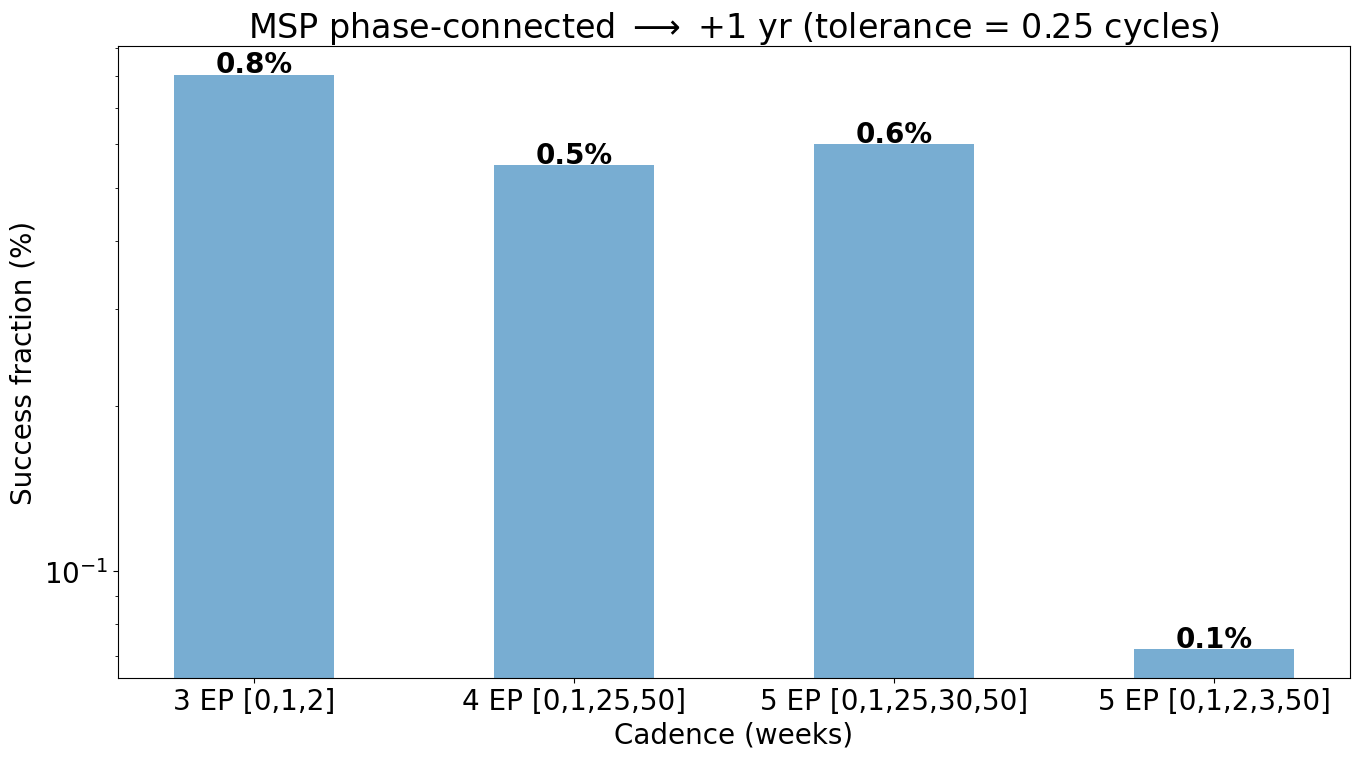

In [4]:
#!/usr/bin/env python3
"""
Simulate the fraction of MSPs that remain phase‑connected after a 1‑year gap
for different observing cadence schedules.

Author: Jakob
Date  : 2025‑06‑03
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Generate an MSP population
# -------------------------------------------------
N_PSR = 50000
rng = np.random.default_rng(42)

# Spin period (ms) – log‑normal around 3 ms
P_ms = 10 ** rng.normal(np.log10(3.0), 0.25, N_PSR)
P_sec = P_ms * 1e-3

# Period derivative – uniform in log space
log10_dotP = rng.uniform(-21, -18, N_PSR)
dotP = 10 ** log10_dotP
dot_nu = -dotP / P_sec**2  # ν̇ = −Ṗ / P²

# Baseline white‑noise TOA uncertainty for a 30‑min dwell (seconds)
sigma_toa_base = 10 ** rng.normal(np.log10(0.7e-6), 0.25, N_PSR)

# Red‑noise amplitude (seconds at 1 yr) – 1–5 µs
A_red = rng.uniform(1, 5, N_PSR) * 1e-6

# DM‑noise amplitude (seconds at 1 yr) – 0.2–1 µs
A_dm = rng.uniform(0.2, 1.0, N_PSR) * 1e-6

# Scintillation S/N factor – log‑normal, σ=0.3 dex
scint_factor = 10 ** rng.normal(0, 0.3, N_PSR)

# -------------------------------------------------
# 2. Helper: robust fraction for a cadence schedule
# -------------------------------------------------
WK2SEC = 7 * 86400
FUTURE_GAP_YEARS = 2
FUTURE_GAP_SEC = FUTURE_GAP_YEARS * 365.25 * 86400

def robust_fraction_full(weeks, thresh=0.05, total_minutes=120):
    """
    Return the % of MSPs that will keep phase coherence over a 1‑year gap
    after observations at the specified 'weeks' epochs.

    Parameters
    ----------
    weeks : list-like
        Epoch timings (weeks since discovery).
    thresh : float
        Allowed 1‑σ phase uncertainty at the future gap (cycles).
    total_minutes : float
        Total telescope time available across all visits (minutes).
    """
    N_visits = len(weeks)
    tint_min = 30 #total_minutes / N_visits            # minutes per visit
    # White‑noise TOA uncertainty scales ∝ 1/√t_int
    sigma_toa = sigma_toa_base * np.sqrt(30.0 / tint_min) * scint_factor

    # Design matrix for ν and ν̇ fits
    t_sec = np.asarray(weeks) * WK2SEC
    t_rel = t_sec - t_sec[0]
    X = np.vstack((np.ones_like(t_rel),              # phase offset
                   t_rel,                            # ν term
                   0.5 * t_rel**2)).T                # ν̇ term
    XtX_inv = np.linalg.inv(X.T @ X)

    var_nu    = XtX_inv[1, 1] * sigma_toa**2
    var_nudot = XtX_inv[2, 2] * sigma_toa**2
    cov       = XtX_inv[1, 2] * sigma_toa**2

    dt = FUTURE_GAP_SEC
    # Prediction error on phase (cycles) propagated to the future gap
    rad = dt**2 * var_nu + 0.25 * dt**4 * var_nudot + 2.0 * dt**3 * cov
    det = np.sqrt(np.maximum(rad, 0.0)) / P_sec

    # Incremental red & DM noise accumulated over the next year
    T_obs_yr = weeks[-1] / 52.0
    incr_red = A_red * ((T_obs_yr + 1.0) ** 2 - T_obs_yr ** 2) / P_sec
    incr_dm  = A_dm  * ((T_obs_yr + 1.0) ** (5/3) - T_obs_yr ** (5/3)) / P_sec

    sigma_phase = np.sqrt(det**2 + incr_red**2 + incr_dm**2)

    # Largest internal gap → risk of cycle‑slip during the campaign
    gap_sec = np.max(np.diff(t_sec))
    drift_cycles = 0.5 * np.abs(dot_nu) * gap_sec**2 / P_sec

    ok = (sigma_phase < thresh) & (drift_cycles < thresh)
    return ok.mean() * 100.0

# -------------------------------------------------
# 3. Evaluate example cadence schedules
# -------------------------------------------------
schedules = {
    "3 EP [0,1,2]":  [0,1,2],
    "4 EP [0,1,25,50]":  [0,1,25,50],
    "5 EP [0,1,25,30,50]":  [0,1,25,30,50],
    "5 EP [0,1,2,3,50]": [0,1,2,3,50],
}

results = {name: robust_fraction_full(weeks,
                                      thresh=0.25,
                                      total_minutes=120)  # 4 × 30 min
           for name, weeks in schedules.items()}

# -------------------------------------------------
# 4. Present results
# -------------------------------------------------
print("Phase‑connected success fraction after 1‑yr gap:")
for name, frac in results.items():
    print(f"  {name:6s} : {frac:5.5f} %")

# Optional quick‑look bar plot
plt.figure(figsize=(14, 8))
percentages = [f"{v:.1f}%" for v in results.values()]
graph = plt.bar(results.keys(), results.values(), alpha=0.6, width=0.5)
i = 0
for p in graph:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    plt.text(x+width/2,
             y+height*1.01,
             str(percentages[i]),
             ha='center',
             weight='bold')
    i += 1
plt.yscale('log')
plt.xlabel("Cadence (weeks)")
plt.ylabel("Success fraction (%)")
plt.title("MSP phase‑connected $\longrightarrow$ +1 yr (tolerance = 0.25 cycles)")
plt.tight_layout()
plt.show()


                          3‑visit very sparse  6‑visit front‑geo  \
Robust % (+1 yr, strict)                100.0              100.0   

                          8‑visit balanced  10‑visit dense  
Robust % (+1 yr, strict)             100.0           100.0  


/Users/jakobfaber/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 8209 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/jakobfaber/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 963 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/jakobfaber/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 8239 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/jakobfaber/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:201: RuntimeWarning: Glyph 8209 missing from current font.
  font.set_text(s, 0, flags=flags)
/Users/jakobfaber/anaconda3/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:201: RuntimeWarning: Glyph 963 missing from current font.
  font.set_text(s, 0, flags=flags)
/Users/jakobfaber/anaconda3/lib/python3.8/site-packages/matplotlib/back

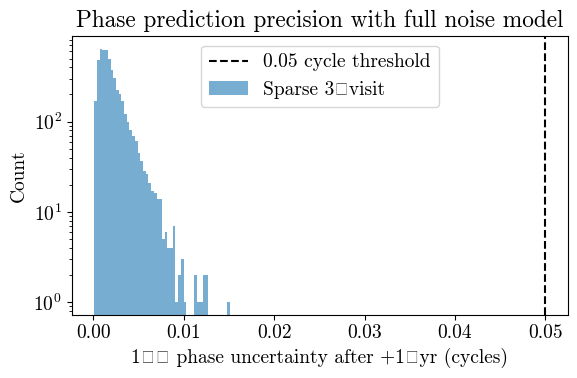

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from ace_tools import display_dataframe_to_user

# -------------------------------------------------
# 1.  Generate MSP population
# -------------------------------------------------
N_PSR = 5000
rng = np.random.default_rng(42)

# spin period (ms) log-normal around 3 ms
P_ms  = 10 ** rng.normal(np.log10(3), 0.25, N_PSR)
P_sec = P_ms * 1e-3

# period derivative uniform in log space
log10_dotP = rng.uniform(-21, -18, N_PSR)
dotP  = 10 ** log10_dotP
dot_nu = -dotP / P_sec**2

# baseline TOA uncertainty for 30‑min dwell (µs → s)
sigma_toa_base = 10 ** rng.normal(np.log10(0.7e-6), 0.25, N_PSR)   # seconds

# Per‑pulsar red‑noise amplitude (µs at 1 yr) — 0.3–2 µs range
A_red_us = rng.uniform(0.3, 2.0, N_PSR)  # microseconds
A_red = A_red_us * 1e-6                  # seconds

# DM‑induced jitter amplitude (µs at 1 yr) 0.2–1 µs
A_dm_us = rng.uniform(0.2, 1.0, N_PSR)
A_dm = A_dm_us * 1e-6

# Scintillation S/N factor: log‑normal, σ=0.3 dex
scint_factor = 10 ** rng.normal(0, 0.3, N_PSR)

# -------------------------------------------------
# 2.  Noise models
# -------------------------------------------------
def red_noise_rms(T_yr, A_red):
    """rms red timing noise (seconds) after quadratic fit"""
    return A_red * (T_yr ** 2)   # ∝ T^2

def dm_noise_rms(T_yr, A_dm):
    """rms DM-driven TOA wander (seconds), power‑law 5/3"""
    return A_dm * (T_yr ** (5/3))

# -------------------------------------------------
# 3.  Robustness calculator
# -------------------------------------------------
wk2sec = 7 * 86400
future_gap_years = 1
future_gap_sec = future_gap_years * 365.25 * 86400
thresh_cycles = 0.05   # tighter: 1‑σ must be <0.05 cycles (i.e., 2σ < 0.1)

def robust_fraction(schedule_weeks, total_minutes=360):
    N = len(schedule_weeks)
    tint_min = total_minutes / N
    if tint_min < 5:
        return -1
    # per-TOA white noise with scintillation & dwell scaling
    sigma_toa = sigma_toa_base * np.sqrt(30 / tint_min) * scint_factor
    
    # times vector
    t_sec = np.array(schedule_weeks) * wk2sec
    t_rel = t_sec - t_sec[0]
    t = t_rel
    X = np.vstack((np.ones_like(t), t, 0.5 * t ** 2)).T
    XtX_inv = np.linalg.inv(X.T @ X)
    
    # parameter variances scaled by sigma_toa^2
    var_nu = XtX_inv[1, 1] * sigma_toa**2
    var_nudot = XtX_inv[2, 2] * sigma_toa**2
    cov_nu_nudot = XtX_inv[1, 2] * sigma_toa**2
    
    dt = future_gap_sec
    sigma_phase_det = np.sqrt(
        (dt ** 2) * var_nu +
        (0.25 * dt ** 4) * var_nudot +
        (dt ** 3) * cov_nu_nudot
    ) / P_sec
    
    T_obs_yr = schedule_weeks[-1] / 52
    # incremental red & DM noise over the future gap
    incr_red = np.sqrt(np.maximum(red_noise_rms(T_obs_yr + future_gap_years, A_red)**2 -
                                  red_noise_rms(T_obs_yr, A_red)**2, 0))
    incr_dm  = np.sqrt(np.maximum(dm_noise_rms(T_obs_yr + future_gap_years, A_dm)**2 -
                                  dm_noise_rms(T_obs_yr, A_dm)**2, 0))
    
    sigma_phase_tot = np.sqrt(sigma_phase_det**2 + (incr_red / P_sec)**2 + (incr_dm / P_sec)**2)
    return (sigma_phase_tot < thresh_cycles).mean() * 100

# -------------------------------------------------
# 4.  Evaluate candidate schedules
# -------------------------------------------------
cand_schedules = {
    "3‑visit very sparse": [0, 1, 52],
    "6‑visit front‑geo":   [0, 1, 3, 7, 19, 52],
    "8‑visit balanced":    [0, 1, 2, 4, 8, 16, 32, 52],
    "10‑visit dense":      [0, 1, 2, 3, 5, 8, 12, 18, 26, 52]
}

results = {name: robust_fraction(weeks) for name, weeks in cand_schedules.items()}
df = pd.DataFrame(results, index=[f"Robust % (+{future_gap_years} yr, strict)"])
print(df)
#display_dataframe_to_user("Robustness with full noise model", df)

# -------------------------------------------------
# 5.  Visualise distribution of total phase σ for two example schedules
# -------------------------------------------------
example1 = [0, 1, 52]
example2 = [0, 1, 3, 7, 19, 52]

def sigma_phase_hist(weeks):
    N = len(weeks)
    tint_min = 360 / N
    sigma_toa = sigma_toa_base * np.sqrt(30 / tint_min) * scint_factor
    t_sec = np.array(weeks) * wk2sec
    t = t_sec - t_sec[0]
    X = np.vstack((np.ones_like(t), t, 0.5 * t ** 2)).T
    XtX_inv = np.linalg.inv(X.T @ X)
    var_nu = XtX_inv[1, 1] * sigma_toa**2
    var_nudot = XtX_inv[2, 2] * sigma_toa**2
    cov_nu_nudot = XtX_inv[1, 2] * sigma_toa**2
    dt = future_gap_sec
    det = np.sqrt((dt ** 2) * var_nu + (0.25 * dt ** 4) * var_nudot + (dt ** 3) * cov_nu_nudot) / P_sec
    T_obs_yr = weeks[-1] / 52
    incr_red = np.sqrt(np.maximum(red_noise_rms(T_obs_yr + 1, A_red)**2 - red_noise_rms(T_obs_yr, A_red)**2, 0))
    incr_dm  = np.sqrt(np.maximum(dm_noise_rms(T_obs_yr + 1, A_dm)**2 - dm_noise_rms(T_obs_yr, A_dm)**2, 0))
    return np.sqrt(det**2 + (incr_red / P_sec)**2 + (incr_dm / P_sec)**2)

sigma1 = sigma_phase_hist(example1)
sigma2 = sigma_phase_hist(example2)

plt.figure(figsize=(6,4))
plt.hist(sigma1, bins=50, alpha=0.6, label="Sparse 3$‑$visit")
#plt.hist(sigma2, bins=50, alpha=0.6, label="6‑visit front‑geo")
plt.axvline(thresh_cycles, color='k', linestyle='--', label="0.05 cycle threshold")
plt.xlabel("1‑σ phase uncertainty after +1 yr (cycles)")
plt.ylabel("Count")
plt.yscale("log")
plt.legend()
plt.title("Phase prediction precision with full noise model")
plt.tight_layout()
plt.show()


In [40]:
print(candidate_rows)

[([0, 1, 3, 7, 19, 52], 6, 2, 100.0), ([0, 1, 2, 6, 18, 52], 6, 3, 100.0), ([0, 1, 2, 3, 12, 52], 6, 4, 100.0), ([0, 1, 2, 3, 4, 52], 6, 5, 100.0), ([0, 1, 2, 5, 11, 24, 52], 7, 2, 100.0), ([0, 1, 2, 5, 10, 23, 52], 7, 3, 100.0), ([0, 1, 2, 3, 8, 20, 52], 7, 4, 100.0), ([0, 1, 2, 3, 4, 14, 52], 7, 5, 100.0), ([0, 1, 2, 3, 4, 5, 52], 7, 6, 100.0), ([0, 1, 2, 4, 7, 14, 27, 52], 8, 2, 100.0), ([0, 1, 2, 4, 7, 14, 27, 52], 8, 3, 100.0), ([0, 1, 2, 3, 6, 12, 25, 52], 8, 4, 100.0), ([0, 1, 2, 3, 4, 9, 22, 52], 8, 5, 100.0), ([0, 1, 2, 3, 4, 5, 16, 52], 8, 6, 100.0), ([0, 1, 2, 3, 5, 10, 17, 30, 52], 9, 2, 100.0), ([0, 1, 2, 3, 6, 10, 18, 30, 52], 9, 3, 100.0), ([0, 1, 2, 3, 5, 9, 17, 29, 52], 9, 4, 100.0), ([0, 1, 2, 3, 4, 8, 14, 27, 52], 9, 5, 100.0), ([0, 1, 2, 3, 4, 5, 11, 24, 52], 9, 6, 100.0), ([0, 1, 2, 3, 4, 7, 12, 19, 32, 52], 10, 2, 100.0), ([0, 1, 2, 3, 5, 8, 13, 20, 33, 52], 10, 3, 100.0), ([0, 1, 2, 3, 5, 8, 12, 20, 32, 52], 10, 4, 100.0), ([0, 1, 2, 3, 4, 7, 11, 19, 31, 52], 10,

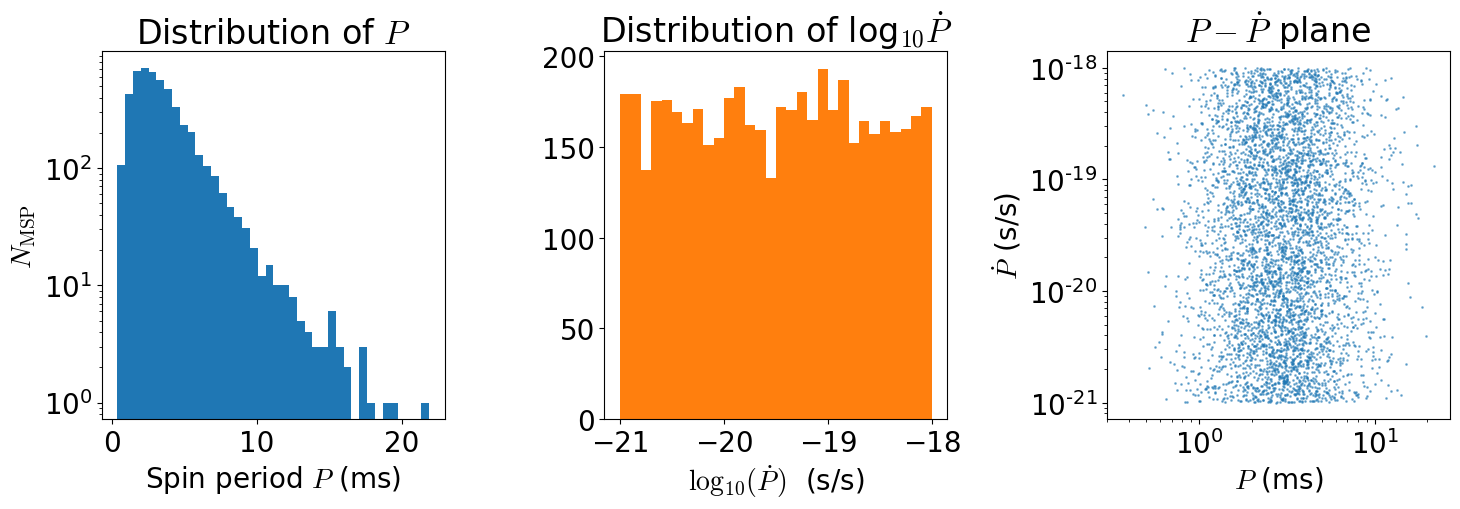

In [123]:
import numpy as np
import matplotlib.pyplot as plt

# Regenerate the MSP population with the same seed and assumptions
N_PSR = 5000
rng = np.random.default_rng(42)
P_ms  = 10**rng.normal(np.log10(3), 0.25, N_PSR)          # log‑normal spin period (ms)
log10_dotP = rng.uniform(-21, -18, N_PSR)                 # uniform in log space
dotP = 10**log10_dotP                                     # period derivative (s/s)

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

# Histogram of spin period
axes[0].hist(P_ms, bins=40, log=True)
axes[0].set_xlabel("Spin period $P$ (ms)")
axes[0].set_ylabel("$N_{\mathrm{MSP}}$")
axes[0].set_title("Distribution of $P$")

# Histogram of log10(dotP)
axes[1].hist(log10_dotP, bins=30, color='tab:orange')
axes[1].set_xlabel(r"$\log_{10}(\dot P)$  (s/s)")
axes[1].set_title("Distribution of log$_{10} \dot P$")

# Scatter P vs dotP
axes[2].loglog(P_ms, dotP, '.', ms=2, alpha=0.5)
axes[2].set_xlabel("$P$ (ms)")
axes[2].set_ylabel(r"$\dot P$ (s/s)")
axes[2].set_title("$P-\dot P$ plane")

plt.tight_layout()
plt.show()
